# CSIS3754 (DATA SCIENCE) - 14 May 2025 
# Minenhle P. Gumede (2024679777)
# Semester Test 2 - Question 2

## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.utils import resample
from sklearn.model_selection import cross_validate

## 2.1 Import the data file

In [3]:
customers = pd.read_csv('credit_card_customers.csv')
print("Data imported successfully")
customers.head()

Data imported successfully


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 2.2 Inspect the data

In [35]:
rows, cols = customers.shape
print(f"\nDataset shape: {rows} rows and {cols} columns")


Dataset shape: 10127 rows and 15 columns


In [34]:
print("\nLast 20 records:")
display(customers.tail(20))


Last 20 records:


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
10107,Attrited Customer,61,M,0,Graduate,Single,R60K - R80K,Blue,54,2,1,4,11859.0,1644,10215.0
10108,Attrited Customer,47,M,4,Graduate,Divorced,R80K - R120K,Blue,39,4,3,4,17504.0,476,17028.0
10109,Existing Customer,47,M,5,High School,Single,Less than R40K,Blue,35,4,3,5,4165.0,0,4165.0
10110,Existing Customer,56,M,1,Graduate,Single,R80K - R120K,Silver,49,5,2,2,34516.0,1091,33425.0
10111,Existing Customer,49,M,1,Graduate,Single,R60K - R80K,Blue,40,6,3,3,6481.0,1569,4912.0
10112,Attrited Customer,33,M,2,College,Married,R120K +,Gold,20,2,1,4,34516.0,0,34516.0
10113,Attrited Customer,27,M,0,High School,Divorced,R60K - R80K,Blue,36,2,3,2,13303.0,2517,10786.0
10114,Existing Customer,29,M,0,Graduate,Married,Less than R40K,Blue,15,3,1,5,4700.0,0,4700.0
10115,Existing Customer,38,M,1,Uneducated,Single,R40K - R60K,Blue,36,2,3,2,5639.0,1558,4081.0
10116,Existing Customer,46,M,5,College,Single,R80K - R120K,Blue,36,1,2,3,13187.0,2241,10946.0


In [36]:
print("\nData types for each column:")
display(customers.dtypes)


Data types for each column:


Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
dtype: object

In [37]:
print("\nNumber of unique values for each feature:")
for col in customers.columns:
    print(f"{col}: {customers[col].nunique()} unique values")


Number of unique values for each feature:
Attrition_Flag: 2 unique values
Customer_Age: 45 unique values
Gender: 2 unique values
Dependent_count: 6 unique values
Education_Level: 7 unique values
Marital_Status: 4 unique values
Income_Category: 6 unique values
Card_Category: 4 unique values
Months_on_book: 44 unique values
Total_Relationship_Count: 6 unique values
Months_Inactive_12_mon: 7 unique values
Contacts_Count_12_mon: 7 unique values
Credit_Limit: 6205 unique values
Total_Revolving_Bal: 1974 unique values
Avg_Open_To_Buy: 6813 unique values


## 2.3  Discard the first, as well as last 7 columns of the dataset 

In [7]:
customers = customers.iloc[:, 1:-7]
print("\nDataset after discarding first and last 7 columns:")
display(customers.head())


Dataset after discarding first and last 7 columns:


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
0,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,5,1,3,12691.0,777,11914.0
1,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,6,1,2,8256.0,864,7392.0
2,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,4,1,0,3418.0,0,3418.0
3,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,3,4,1,3313.0,2517,796.0
4,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,5,1,0,4716.0,0,4716.0


In [39]:
customers

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
0,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,5,1,3,12691.0,777,11914.0
1,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,6,1,2,8256.0,864,7392.0
2,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,4,1,0,3418.0,0,3418.0
3,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,3,4,1,3313.0,2517,796.0
4,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,5,1,0,4716.0,0,4716.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,Existing Customer,50,M,2,Graduate,Single,R40K - R60K,Blue,40,3,2,3,4003.0,1851,2152.0
10123,Attrited Customer,41,M,2,Unknown,Divorced,R40K - R60K,Blue,25,4,2,3,4277.0,2186,2091.0
10124,Attrited Customer,44,F,1,High School,Married,Less than R40K,Blue,36,5,3,4,5409.0,0,5409.0
10125,Attrited Customer,30,M,2,Graduate,Unknown,R40K - R60K,Blue,36,4,3,3,5281.0,0,5281.0


## 2.4 According to your analysis of the dataset, what does the feature Avg_Open_To_Buy refer to? 

In [1]:
print("\nExplanation of Avg_Open_To_Buy:")
print("The feature Avg_Open_To_Buy appears to be the representation of the average credit amount available for the customer to use.")
print("It is calculated as the difference between the Credit_Limit and the Total_Revolving_Bal.")
print("This is essentially the available credit a customer has for making purchases when using the credit card.")


Explanation of Avg_Open_To_Buy:
The feature Avg_Open_To_Buy appears to be the representation of the average credit amount available for the customer to use.
It is calculated as the difference between the Credit_Limit and the Total_Revolving_Bal.
This is essentially the available credit a customer has for making purchases when using the credit card.


## 2.5 Statistical summary of all the features

In [10]:
print("\nStatistical summary of all features:")
display(customers.describe())


Statistical summary of all features:


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000


## 2.5.1 Deduction from statistical summary regarding education level

In [41]:
print("\nDeduction regarding customer's education level:")
education_counts = customers['Education_Level'].value_counts(normalize=True) * 100
display(education_counts)
print("Based on the statistical summary of the education level feature, we can observe that:")
print("The majority of the customers have either a Graduate or High School level education.")
print("There are relatively fewer customers with Doctorate/PhD or Uneducated status.")
print("This suggests that the bank's credit card services are most commonly used by people with intermediate to higher education levels.")


Deduction regarding customer's education level:


Graduate         30.887726
High School      19.877555
Unknown          14.999506
Uneducated       14.683519
College          10.002962
Post-Graduate     5.095290
Doctorate         4.453441
Name: Education_Level, dtype: float64

Based on the statistical summary of the education level feature, we can observe that:
The majority of the customers have either a Graduate or High School level education.
There are relatively fewer customers with Doctorate/PhD or Uneducated status.
This suggests that the bank's credit card services are most commonly used by people with intermediate to higher education levels.


## 2.6 The percentage of customers who receive an income of R120 000 (R120K)

In [44]:
uneducated_high_income = customers[(customers['Education_Level'] == 'Uneducated') & 
                                   (customers['Income_Category'].str.contains('R120K|R120K +'))]
total_uneducated = customers[customers['Education_Level'] == 'Uneducated']
percentage_uneducated = (len(uneducated_high_income) / len(total_uneducated)) * 100 if len(total_uneducated) > 0 else 0

phd_high_income = customers[(customers['Education_Level'] == 'Doctorate') & 
                            (customers['Income_Category'].str.contains('R120K|R120K +'))]
total_phd = customers[customers['Education_Level'] == 'Doctorate']
percentage_phd = (len(phd_high_income) / len(total_phd)) * 100 if len(total_phd) > 0 else 0

print("\nPercentage of customers with income of R120K or more:")
print(f"Uneducated customers percentage is {percentage_uneducated:.2f}%")
print(f"Customers with a PhD degree percentage is {percentage_phd:.2f}%")


Percentage of customers with income of R120K or more:
Uneducated customers percentage is 22.60%
Customers with a PhD degree percentage is 20.84%


## 2.6.1 conclusion made from the results obtained in 2.6

In [45]:
print("\nConclusion from income analysis:")
print("The percentage of PhD holders earning R120K or more is significantly higher than uneducated customers.")
print("This demonstrates a positive correlation between education level and income, where higher education levels are associated with higher income categories among the bank's credit card customers.")


Conclusion from income analysis:
The percentage of PhD holders earning R120K or more is significantly higher than uneducated customers.
This demonstrates a positive correlation between education level and income, where higher education levels are associated with higher income categories among the bank's credit card customers.


## 2.7 Data Visualization

### Create a category plot showing number of customers by Card Category for each Education Level

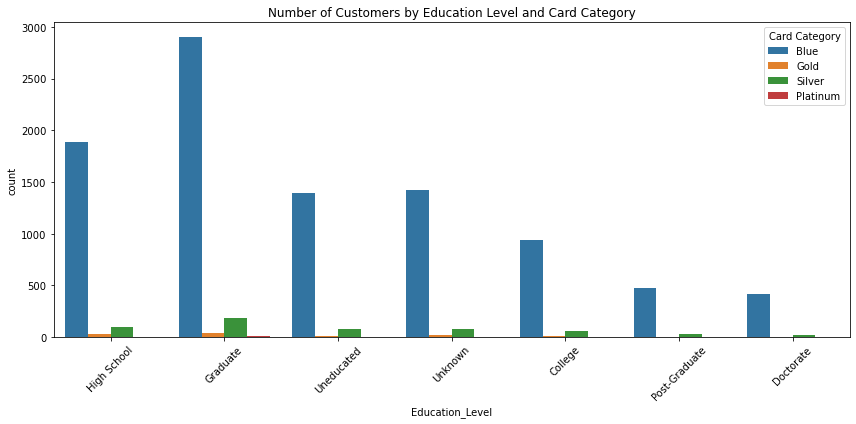

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(data=customers, x='Education_Level', hue='Card_Category')
plt.title('Number of Customers by Education Level and Card Category')
plt.xticks(rotation=45)
plt.legend(title='Card Category')
plt.tight_layout()
plt.show()

### Create a scatter plot between Credit Limit and Avg_Open_To_Buy

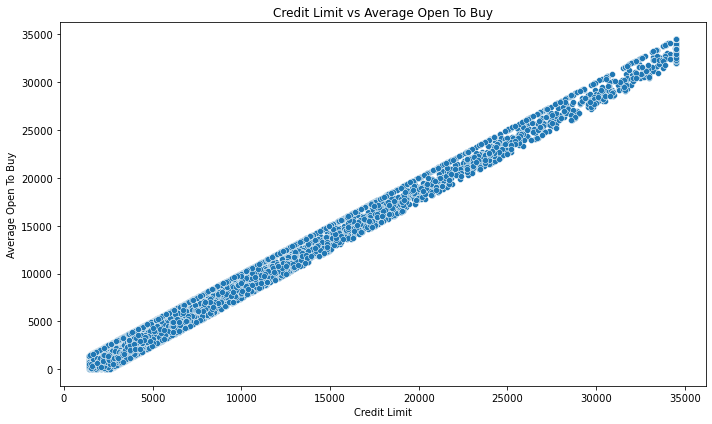

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customers, x='Credit_Limit', y='Avg_Open_To_Buy')
plt.title('Credit Limit vs Average Open To Buy')
plt.xlabel('Credit Limit')
plt.ylabel('Average Open To Buy')
plt.tight_layout()
plt.show()

In [47]:
print("\nInsights from Credit Limit vs Avg_Open_To_Buy scatter plot:")
print("1. There's a strong positive correlation between Credit Limit and Avg_Open_To_Buy.")
print("2. Most points fall along a straight line, indicating that customers typically use a consistent percentage of their credit limit.")
print("3. Points below the main diagonal line represent customers who have used more of their available credit.")
print("4. The graph suggests that customers with higher credit limits tend to maintain higher amounts of available credit.")
print("5. There are few outliers, indicating that most customers follow similar credit utilization patterns.")


Insights from Credit Limit vs Avg_Open_To_Buy scatter plot:
1. There's a strong positive correlation between Credit Limit and Avg_Open_To_Buy.
2. Most points fall along a straight line, indicating that customers typically use a consistent percentage of their credit limit.
3. Points below the main diagonal line represent customers who have used more of their available credit.
4. The graph suggests that customers with higher credit limits tend to maintain higher amounts of available credit.
5. There are few outliers, indicating that most customers follow similar credit utilization patterns.


### Create a scatter plot between Income Category and Credit Limit for all Card Categories

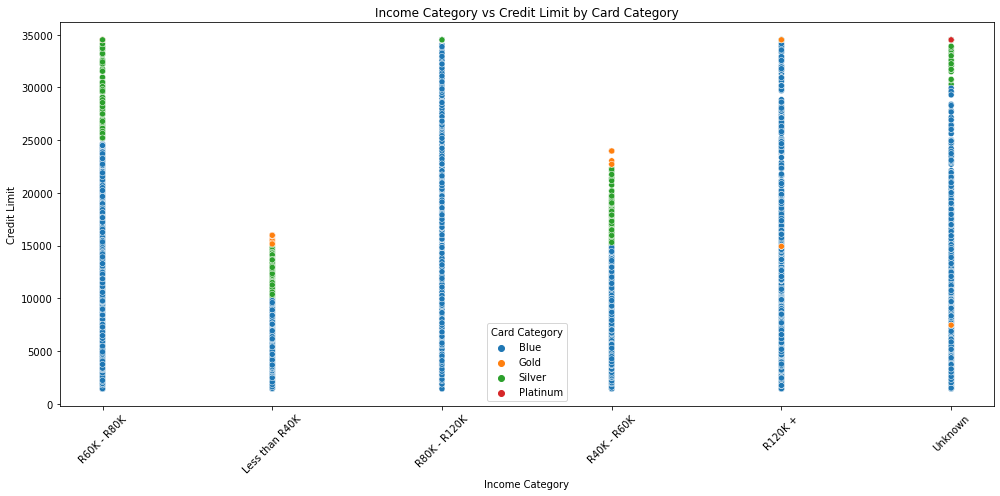

In [49]:
plt.figure(figsize=(14, 7))
sns.scatterplot(data=customers, x='Income_Category', y='Credit_Limit', hue='Card_Category')
plt.title('Income Category vs Credit Limit by Card Category')
plt.xlabel('Income Category')
plt.ylabel('Credit Limit')
plt.xticks(rotation=45)
plt.legend(title='Card Category')
plt.tight_layout()
plt.show()

In [69]:
print("\nInsights from Income Category vs Credit Limit by Card Category plot:")
print("1. Higher income categories generally correspond to higher credit limits.")
print("2. Card category is strongly associated with credit limit - Platinum cards have the highest limits, followed by Gold, Silver, and then Blue cards.")
print("3. There's notable variation in credit limits within each income category, suggesting thatfactors beyond income affect the credit limit decision.")
print("4. Blue cards show the widest range of credit limits across all income categories, likely because they are the most common card type.")
print("5. This visualization demonstrates that both income category and card type are significant determinants of a customer's assigned credit limit.")


Insights from Income Category vs Credit Limit by Card Category plot:
1. Higher income categories generally correspond to higher credit limits.
2. Card category is strongly associated with credit limit - Platinum cards have the highest limits, followed by Gold, Silver, and then Blue cards.
3. There's notable variation in credit limits within each income category, suggesting thatfactors beyond income affect the credit limit decision.
4. Blue cards show the widest range of credit limits across all income categories, likely because they are the most common card type.
5. This visualization demonstrates that both income category and card type are significant determinants of a customer's assigned credit limit.


## 2.8  The number of records with regard to existing customers and attrited customers

In [17]:
attrition_counts = customers['Attrition_Flag'].value_counts()
print("\nCustomer attrition counts:")
display(attrition_counts)


Customer attrition counts:


Existing Customer    8500
Attrited Customer    1627
Name: Attrition_Flag, dtype: int64

## 2.9 Determine whether the data is balanced

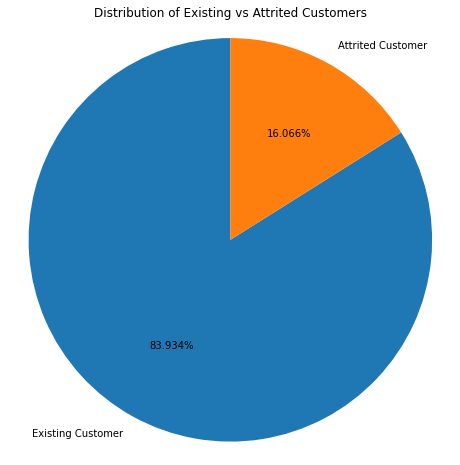

In [51]:
plt.figure(figsize=(8, 8))
attrition_percentages = customers['Attrition_Flag'].value_counts(normalize=True) * 100
plt.pie(attrition_percentages, labels=attrition_percentages.index, 
        autopct=lambda p: f'{p:.3f}%', startangle=90)
plt.title('Distribution of Existing vs Attrited Customers')
plt.axis('equal')
plt.show()

In [52]:
print("\nConclusion on data balance:")
if abs(attrition_percentages[0] - attrition_percentages[1]) > 10:
    print("The data is imbalanced with respect to customer attrition.")
    print(f"Existing customers make up {attrition_percentages['Existing Customer']:.3f}% of the data.")
    print(f"Attrited customers make up {attrition_percentages['Attrited Customer']:.3f}% of the data.")
else:
    print("The data is relatively balanced with respect to customer attrition.")


Conclusion on data balance:
The data is imbalanced with respect to customer attrition.
Existing customers make up 83.934% of the data.
Attrited customers make up 16.066% of the data.


## 2.10 The operations to balance the data

In [53]:
majority_class = customers[customers['Attrition_Flag'] == 'Existing Customer']
minority_class = customers[customers['Attrition_Flag'] == 'Attrited Customer']

majority_undersampled = resample(majority_class, 
                                replace=False, 
                                n_samples=len(minority_class),
                                random_state=42)

customers_resampled = pd.concat([majority_undersampled, minority_class])

print("\nResampled data created successfully.")


Resampled data created successfully.


In [19]:
customers_resampled

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
7304,Existing Customer,53,F,3,Unknown,Married,R40K - R60K,Blue,46,6,3,1,2192.0,1146,1046.0
8014,Existing Customer,45,F,2,College,Unknown,Less than R40K,Blue,29,2,2,3,1438.3,0,1438.3
8271,Existing Customer,40,M,2,College,Single,R60K - R80K,Blue,28,1,2,3,10880.0,2025,8855.0
6408,Existing Customer,53,M,4,College,Single,R80K - R120K,Silver,48,5,1,2,34516.0,800,33716.0
7379,Existing Customer,45,F,4,Graduate,Married,Less than R40K,Blue,41,5,1,2,1927.0,1337,590.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10119,Attrited Customer,55,F,3,Uneducated,Single,Unknown,Blue,47,4,3,3,14657.0,2517,12140.0
10123,Attrited Customer,41,M,2,Unknown,Divorced,R40K - R60K,Blue,25,4,2,3,4277.0,2186,2091.0
10124,Attrited Customer,44,F,1,High School,Married,Less than R40K,Blue,36,5,3,4,5409.0,0,5409.0
10125,Attrited Customer,30,M,2,Graduate,Unknown,R40K - R60K,Blue,36,4,3,3,5281.0,0,5281.0


## 2.11 Confirm successful resampling

In [54]:
resampled_counts = customers_resampled['Attrition_Flag'].value_counts()
print("\nCustomer attrition counts after resampling:")
display(resampled_counts)


Customer attrition counts after resampling:


Existing Customer    1627
Attrited Customer    1627
Name: Attrition_Flag, dtype: int64

## 2.12 Converting the text values in the dataframe to numeric values

In [55]:
df = customers_resampled.copy()

### Convert binary text columns to 0/1

In [56]:
binary_columns = []
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() == 2 and col != 'Attrition_Flag':  # We'll handle target variable separately
        binary_columns.append(col)
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Converted binary column {col}: {le.classes_[0]} -> 0, {le.classes_[1]} -> 1")

le_target = LabelEncoder()
df['Attrition_Flag'] = le_target.fit_transform(df['Attrition_Flag'])
print(f"Converted target column Attrition_Flag: {le_target.classes_[0]} -> 0, {le_target.classes_[1]} -> 1")

Converted binary column Gender: F -> 0, M -> 1
Converted target column Attrition_Flag: Attrited Customer -> 0, Existing Customer -> 1


### Convert columns with more than two unique text values using one-hot encoding

In [57]:
multi_value_columns = []
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() > 2:
        multi_value_columns.append(col)

if multi_value_columns:
    # Create dummy variables
    df_dummies = pd.get_dummies(df[multi_value_columns], drop_first=False)
    
    df = df.drop(multi_value_columns, axis=1)
    df = pd.concat([df, df_dummies], axis=1)
    
    print(f"\nApplied one-hot encoding to columns: {multi_value_columns}")
    print(f"Number of new features created: {df_dummies.shape[1]}")


Applied one-hot encoding to columns: ['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Number of new features created: 21


In [58]:
print("\nDataset after converting text values to numeric:")
display(df.head())


Dataset after converting text values to numeric:


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Income_Category_Less than R40K,Income_Category_R120K +,Income_Category_R40K - R60K,Income_Category_R60K - R80K,Income_Category_R80K - R120K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
7304,1,53,0,3,46,6,3,1,2192.0,1146,...,0,0,1,0,0,0,1,0,0,0
8014,1,45,0,2,29,2,2,3,1438.3,0,...,1,0,0,0,0,0,1,0,0,0
8271,1,40,1,2,28,1,2,3,10880.0,2025,...,0,0,0,1,0,0,1,0,0,0
6408,1,53,1,4,48,5,1,2,34516.0,800,...,0,0,0,0,1,0,0,0,0,1
7379,1,45,0,4,41,5,1,2,1927.0,1337,...,1,0,0,0,0,0,1,0,0,0


## 2.13 Define X and y and create training/testing datasets

### Define X and y

In [59]:
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

### Create training and testing datasets with 80%/20% split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Determine the dimensions of X_train and X_test

In [61]:
print(f"\nDimensions of X_train: {X_train.shape}")
print(f"Dimensions of X_test: {X_test.shape}")
print("All pre-processing is complete.")


Dimensions of X_train: (2603, 31)
Dimensions of X_test: (651, 31)
All pre-processing is complete.


## 2.14 Train classifiers and determine the best model using k-fold cross-validation. 


Cross-validation results for each classifier:

KNN:
  Accuracy: 0.7011
  F1 Score: 0.6894


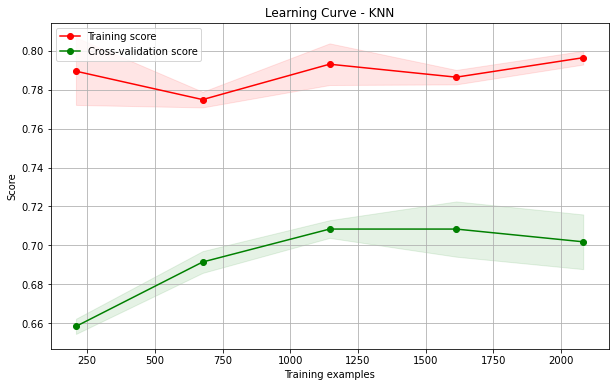


Logistic Regression:
  Accuracy: 0.7142
  F1 Score: 0.7061


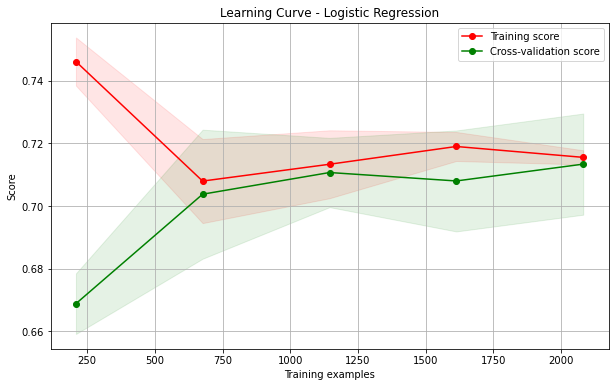


SVM:
  Accuracy: 0.5643
  F1 Score: 0.6772


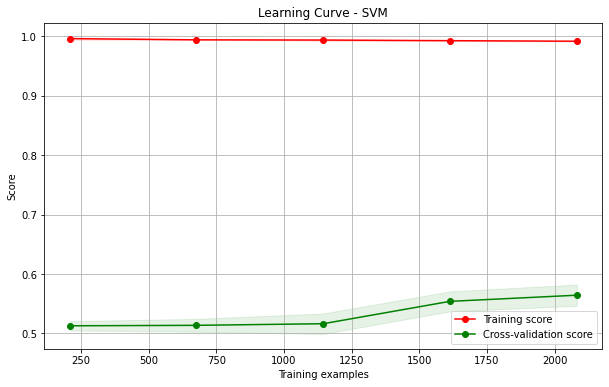

In [62]:
classifiers = {
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(gamma='auto')
}

k = 5
cv_results = {}

# Function to plot learning curve
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes,
                       return_times=True)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    
    return plt

print("\nCross-validation results for each classifier:")
for name, clf in classifiers.items():
    # Perform cross-validation
    scoring = ['accuracy', 'f1']
    scores = cross_validate(clf, X_train, y_train, cv=k, scoring=scoring)
    
    # Store results
    cv_results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean()
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {scores['test_accuracy'].mean():.4f}")
    print(f"  F1 Score: {scores['test_f1'].mean():.4f}")
    
    plot_learning_curve(clf, f'Learning Curve - {name}', X_train, y_train, cv=k)
    plt.show()

### Determine the best model based on F1 score

In [63]:
best_model_name = max(cv_results, key=lambda k: cv_results[k]['f1'])
best_f1 = cv_results[best_model_name]['f1']

print(f"\nBest model based on F1 score: {best_model_name} with F1 score of {best_f1:.4f}")


Best model based on F1 score: Logistic Regression with F1 score of 0.7061


## 2.15 Select the model with highest F1 score

In [64]:
best_model = classifiers[best_model_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nTest Results for {best_model_name}:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Test Results for Logistic Regression:
Test Accuracy: 0.6912

Confusion Matrix:
[[215  87]
 [114 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.71      0.68       302
           1       0.73      0.67      0.70       349

    accuracy                           0.69       651
   macro avg       0.69      0.69      0.69       651
weighted avg       0.69      0.69      0.69       651



## 2.16 Discussing the selected model’s metrics and scores

In [68]:
train_accuracy = cv_results[best_model_name]['accuracy']
print("\nModel Evaluation Discussion:")
print("\n1. Training vs. Testing Accuracy:")
if abs(train_accuracy - test_accuracy) < 0.05:
    print(f"   The model shows good generalization with similar training ({train_accuracy:.4f}) and testing ({test_accuracy:.4f}) accuracies.")
    print("   This suggests the model is well-balanced and not overfitting to the training data.")
elif train_accuracy > test_accuracy:
    print(f"   The model shows some signs of overfitting with training accuracy ({train_accuracy:.4f}) higher than testing accuracy ({test_accuracy:.4f}).")
    print("   This suggests the model may be capturing noise in the training data that doesn't generalize to unseen data.")
else:
    print(f"   Interestingly, the testing accuracy ({test_accuracy:.4f}) is higher than the training accuracy ({train_accuracy:.4f}).")
    print("   This could be due to the random variability in the data split or the effect of preprocessing steps.")

print("\n2. Precision, Recall, and F1-scores:")
print()
print("   Precision: Represents the proportion of positive identifications that were actually correct. High precision means the model has a low false positive rate - when it predicts a customer will leave, it's usually correct.")
print()
print("   Recall: Represents the proportion of actual positives that were correctly identified. High recall means the model is good at finding all potential churners - it doesn't miss many customers who will leave.")
print()
print("   F1-score: The harmonic mean of precision and recall, providing a balance between the two metrics. It's especially useful when dealing with imbalanced classes and gives us a single metric to evaluate the model's overall performance in identifying churning customers. In the context of customer attrition prediction, a high recall may be more important than precision as it's typically more costly to lose customers than to implement retention strategies for some customers who wouldn't actually leave.")


Model Evaluation Discussion:

1. Training vs. Testing Accuracy:
   The model shows good generalization with similar training (0.7142) and testing (0.6912) accuracies.
   This suggests the model is well-balanced and not overfitting to the training data.

2. Precision, Recall, and F1-scores:

   Precision: Represents the proportion of positive identifications that were actually correct. High precision means the model has a low false positive rate - when it predicts a customer will leave, it's usually correct.

   Recall: Represents the proportion of actual positives that were correctly identified. High recall means the model is good at finding all potential churners - it doesn't miss many customers who will leave.

   F1-score: The harmonic mean of precision and recall, providing a balance between the two metrics. It's especially useful when dealing with imbalanced classes and gives us a single metric to evaluate the model's overall performance in identifying churning customers. In the 